Drift spike regions don't contain real physiological information. So, it's just noise. Removal would be better than normalization.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
CV1_PATH = r"D:\programming\rPPg\cv_1\cv1_output.json"

with open(CV1_PATH, "r") as f:
    data = json.load(f)

subjects = data["subjects"]

In [3]:
DRIFT_PATH = r"D:\programming\rPPg\drift\drift_output.json"

with open(DRIFT_PATH, "r") as f:
    drift_data = json.load(f)

Drift Removal

In [4]:
def remove_drift(time, signal, drift_windows):
    mask = np.ones(len(time), dtype=bool)
    #assume all signal points are valid
    for w in drift_windows:
        start = w["start_time"]
        end = w["end_time"]
        mask &= ~((time >= start) & (time <= end))
        #mark points within drift windows as invalid
    clean_time = time[mask]
    clean_signal = signal[mask]
    #return only the valid points, corrupted points are removed
    return clean_time, clean_signal

Bandpass Filter

In [5]:
from scipy.signal import butter, filtfilt
#Bandpass filter to isolate heart rate frequencies (0.7 - 3 Hz)
def bandpass_filter(signal, fps, low=0.7, high=3):
    nyquist = 0.5 * fps #Nyquist frequency is half the sampling rate
    low = low / nyquist
    high = high / nyquist
    b, a = butter(4, [low, high], btype='band')#3rd order Butterworth filter
    #Apply zero-phase filtering to avoid phase distortion
    filtered = filtfilt(b, a, signal)
    return filtered


Heart Rate Estimation

In [6]:
def estimate_hr(signal, fs):

    N = len(signal)

    yf = np.abs(np.fft.rfft(signal))
    xf = np.fft.rfftfreq(N, 1/fs)

    mask = (xf >= 0.7) & (xf <= 3.0)

    xf = xf[mask]
    yf = yf[mask]

    peak_freq = xf[np.argmax(yf)]

    hr = peak_freq * 60

    return hr

Test on 1 subject(Debug)

In [7]:
subject_id = "Subject_1"
roi = "forehead"
#Access the ROI signal extracted from CV1 data 
roi_data = subjects[subject_id]["per_frame_rgb"][roi]

time = np.array(roi_data["time_seconds"])
G = np.array(roi_data["G_per_frame"])
R = np.array(roi_data["R_per_frame"])
B = np.array(roi_data["B_per_frame"])
#Loads the drift windows for the subject and ROI from the drift detection results
drift_windows = drift_data[subject_id][roi]

In [8]:
fps = 1 / np.mean(np.diff(time))

rppg = G - (0.5 * R + 0.5 * B)
rppg = (rppg - np.mean(rppg)) / np.std(rppg)

filtered_signal = bandpass_filter(rppg, fps)

hr_raw = estimate_hr(filtered_signal, fps)

clean_time, clean_signal = remove_drift(time, G, drift_windows)
fps_clean = 1 / np.mean(np.diff(clean_time))
filtered_clean = bandpass_filter(clean_signal, fps_clean)

hr_clean = estimate_hr(filtered_clean, fps_clean)

In [9]:
print(f"Estimated HR before drift removal: {hr_raw:.2f} bpm")
print(f"Estimated HR after drift removal: {hr_clean:.2f} bpm")

Estimated HR before drift removal: 102.23 bpm
Estimated HR after drift removal: 69.62 bpm


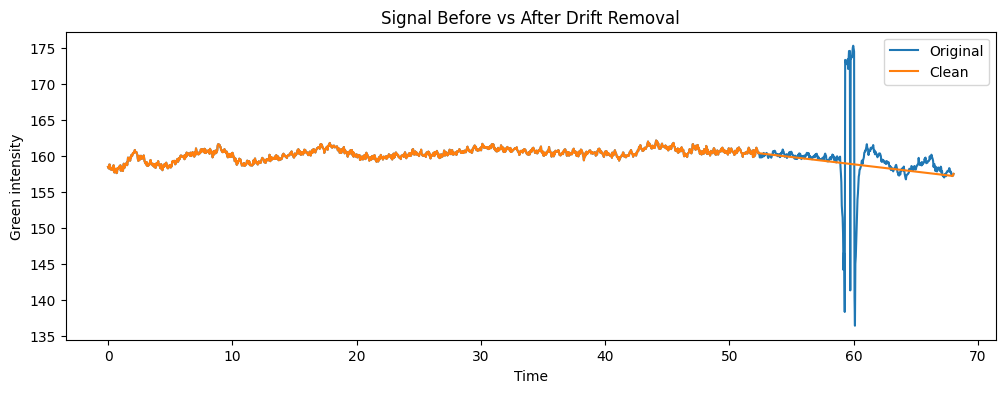

In [10]:
plt.figure(figsize=(12,4))

plt.plot(time, G, label="Original")
plt.plot(clean_time, clean_signal, label="Clean")

plt.title("Signal Before vs After Drift Removal")
plt.xlabel("Time")
plt.ylabel("Green intensity")

plt.legend()
plt.show()

In [11]:
results = {}
drift_summary = {}

for subject_id, subject in subjects.items():

    print("\nProcessing:", subject_id)

    results[subject_id] = {}
    drift_summary[subject_id] = {}

    for roi in ["forehead", "left_cheek", "right_cheek"]:

        roi_data = subject["per_frame_rgb"][roi]

        time = np.array(roi_data["time_seconds"])
        R = np.array(roi_data["R_per_frame"])
        G = np.array(roi_data["G_per_frame"])
        B = np.array(roi_data["B_per_frame"])

        fps = 1 / np.mean(np.diff(time))

        # ----- Construct rPPG signal -----
        rppg = G - (0.5 * R + 0.5 * B)
        rppg = rppg - np.mean(rppg)

        # ----- HR before drift removal -----
        filtered_signal = bandpass_filter(rppg, fps)
        hr_raw = estimate_hr(filtered_signal, fps)

        # ----- Get drift windows -----
        drift_windows = drift_data[subject_id][roi]

        # ----- Save drift segments -----
        drift_summary[subject_id][roi] = []
        for w in drift_windows:
            drift_summary[subject_id][roi].append({
                "start": float(w["start_time"]),
                "end": float(w["end_time"])
            })

        # ----- Remove drift -----
        clean_time, clean_signal = remove_drift(time, rppg, drift_windows)

        # ----- Interpolate to restore signal length -----
        from scipy.interpolate import interp1d
        interp = interp1d(clean_time, clean_signal, fill_value="extrapolate")
        signal_resampled = interp(time)

        # ----- HR after drift removal -----
        filtered_clean = bandpass_filter(signal_resampled, fps)
        hr_clean = estimate_hr(filtered_clean, fps)

        results[subject_id][roi] = {
            "hr_before_drift": float(round(hr_raw, 2)),
            "hr_after_drift": float(round(hr_clean, 2))
        }

        print(roi, "→ Raw:", round(hr_raw, 2), "Clean:", round(hr_clean, 2))

    # ----- Final HR from ROIs (median) -----
    roi_values = [
        results[subject_id]["forehead"]["hr_after_drift"],
        results[subject_id]["left_cheek"]["hr_after_drift"],
        results[subject_id]["right_cheek"]["hr_after_drift"]
    ]

    results[subject_id]["final_hr"] = float(np.median(roi_values))

# ----- Save HR results -----
with open("hr_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("\nHR results saved.")

# ----- Save drift segments -----
with open("drift_segments_summary.json", "w") as f:
    json.dump(drift_summary, f, indent=4)

print("Drift segment summary saved.")


Processing: Subject_1
forehead → Raw: 102.23 Clean: 91.66
left_cheek → Raw: 78.44 Clean: 68.74
right_cheek → Raw: 134.84 Clean: 80.2

Processing: Subject_2
forehead → Raw: 104.42 Clean: 104.42
left_cheek → Raw: 104.42 Clean: 121.45
right_cheek → Raw: 121.45 Clean: 121.45

Processing: Subject_3
forehead → Raw: 92.53 Clean: 92.53
left_cheek → Raw: 63.0 Clean: 48.24
right_cheek → Raw: 69.89 Clean: 69.89

Processing: Subject_4
forehead → Raw: 111.68 Clean: 102.59
left_cheek → Raw: 89.61 Clean: 89.61
right_cheek → Raw: 116.88 Clean: 116.88

Processing: Subject_5
forehead → Raw: 111.75 Clean: 111.75
left_cheek → Raw: 47.89 Clean: 60.31
right_cheek → Raw: 61.2 Clean: 53.21

Processing: Subject_6
forehead → Raw: 68.19 Clean: 68.19
left_cheek → Raw: 50.48 Clean: 81.48
right_cheek → Raw: 61.11 Clean: 60.22

Processing: Subject_7
forehead → Raw: 70.19 Clean: 127.23
left_cheek → Raw: 57.03 Clean: 64.93
right_cheek → Raw: 48.26 Clean: 84.23

Processing: Subject_8
forehead → Raw: 65.68 Clean: 67.43